# CLASIFICADOR ODS - MICROPROYECTO 2

**Objetivo:** Desarrollar una solución automatizada basada en Procesamiento de Lenguaje Natural (NLP) y Machine Learning para clasificar textos de acuerdo con los 17 Objetivos de Desarrollo Sostenible (ODS) de la Agenda 2030 de la ONU.

Este Jupyter Notebook contiene el pipeline completo y se desarrolla cada paso a continuación.


In [93]:
# Se importan  las librerias a utilizar para el desarrollo
import pandas as pd
import numpy as np
import warnings
import re
import os
import spacy
from nltk.corpus import stopwords
import nltk
import string
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, f1_score, confusion_matrix, accuracy_score
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", message=".*multiprocessing.*")
os.environ['PYTHONWARNINGS'] = 'ignore:urllib3 v2 only supports OpenSSL'

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

True

#### PASO 1: Carga y Exploración de los Datos

In [85]:
# PASO 1: Carga y Exploración de los Datos
# Se procede a cargar el dataset para entender mejor el tipo de datos y sus dimensiones.
df = pd.read_excel('../data.xlsx')

# Se visualiza una parte de los datos cargados. Se aprecia que el dataset tiene 9656 filas y 2 columnas
df

,textos,ODS
0,"""Aprendizaje"" y ""educación"" se consideran sinó...",4
1,No dejar clara la naturaleza de estos riesgos ...,6
2,"Como resultado, un mayor y mejorado acceso al ...",13
3,Con el Congreso firmemente en control de la ju...,16
4,"Luego, dos secciones finales analizan las impl...",5
...,...,...
9651,Esto implica que el tiempo de las mujeres en e...,5
9652,"Sin embargo, estas fallas del mercado implican...",3
9653,El hecho de hacerlo y cómo hacerlo dependerá e...,9
9654,"Esto se destacó en el primer estudio de caso, ...",6


### Limpieza de los datos

In [24]:
#Se revisan si existen datos duplicados y datos nulos
print(f'Cantidad de datos duplicados: {df.duplicated().sum()}')
print(f'Cantidad de datos Nulos:\n{df.isna().sum()}')


Cantidad de datos duplicados: 0
Cantidad de datos Nulos:
textos    0
ODS       0
dtype: int64


In [84]:
# Se verifica si hay textos que son solo espacios en blanco
blank_spaces = df[df['textos'].str.strip() == ''].shape[0]
print(f'Textos vacíos con solo espacios: {blank_spaces}')

# Se verifica el balance de los ODS
print("\nDistribución de etiquetas (ODS):")
print(df['ODS'].value_counts().sort_index())

Textos vacíos con solo espacios: 0

Distribución de etiquetas (ODS):
ODS
1      505
2      369
3      894
4     1025
5     1070
6      695
7      787
8      446
9      343
10     352
11     607
12     312
13     464
14     377
15     330
16    1080
Name: count, dtype: int64


#### De los anteriores resultados se aprecia:
1. Hay clases desbalanceadas y podría llevar a que el modelo sea más preciso con las clases mayoritarias. Para compensar este desbalance, se configurará el clasificador con 'class_weight='balanced'

2. Se observa que el dataset cuenta con 16 categorías de ODS (del 1 al 16). El ODS 17 ('Alianzas para lograr los objetivos') no está presente en la muestra. Para efectos del modelo, se trabajará con las 16 clases disponibles, asegurando que el pipeline identifique correctamente las temáticas específicas de cada una

### Limpieza de todos los textos

- Se optó por la lematización mediante la libreria spaCy en lugar de un proceso de stemming convencional. Esto permite reducir la variabilidad del vocabulario manteniendo la integridad semántica de los términos
- Por otro lado, spaCy presenta una capacidad superior para la lematización en español
- Honnibal, M., & Montani, I. (2017): Los creadores de spaCy explican que el modelo de diseño "Industrial-Strength NLP" prioriza la precisión lingüística sobre los métodos de recorte mecánicos (como el stemming de Porter)

In [83]:
# Se cargan los recursos de NLP, con la libreria en español
nlp = spacy.load("es_core_news_sm")
stop_words = set(stopwords.words('spanish'))

#Se define la función que realizará la limpieza de los textos
def limpieza_textos(text):
    
    # Limpieza básica: pasar todo a minúsculas
    text = text.lower()
    
    # Procesamiento con spaCy para la Lematización de los textos
    doc = nlp(text)
    
    # Filtrado y Lematización
    # Solo palabras alfabéticas, sin stopwords, sin puntuación
    # Se extrae el lemma (raíz) para normalizar el vocabulario
    tokens_limpios = [
        token.lemma_ for token in doc 
        if not token.is_stop and not token.is_punct and token.is_alpha
        and token.lemma_ not in stop_words
    ]
    return " ".join(tokens_limpios)

print("Iniciando preprocesamiento paralelo...")

# Se usa n_process=-1 para activar todos los núcleos del PC
# Esta decisión técnica permite manejar el volumen de datos de manera eficiente, reduciendo los tiempos de preprocesamiento sin sacrificar 
#   la calidad del análisis lingüístico necesario para identificar los 16 ODS
docs = nlp.pipe(df['textos'].tolist(), n_process=-1, batch_size=500)

# Se reconstruye la lista aplicando la lógica de filtrado de la función 'limpieza_textos'
textos_procesados = []
for doc in docs:
    tokens = [
        token.lemma_ for token in doc 
        if not token.is_stop and not token.is_punct and token.is_alpha
        and token.lemma_ not in stop_words
    ]
    textos_procesados.append(" ".join(tokens))

df['texto_limpio'] = textos_procesados
print("¡Preprocesamiento completado!")

Iniciando preprocesamiento paralelo...
¡Preprocesamiento completado!


In [35]:
# Se verifica que la columna se haya creado correctamente
print(f"Muestras procesadas: {len(df['texto_limpio'])}")
print(df[['textos', 'texto_limpio']].head(2))

Muestras procesadas: 9656
                                              textos  \
0  "Aprendizaje" y "educación" se consideran sinó...   
1  No dejar clara la naturaleza de estos riesgos ...   

                                        texto_limpio  
0  aprendizaje educación considerar sinónir escol...  
1  dejar claro naturaleza riesgo lugar exceso inv...  


En el ejemplo de arriba se observa que se elimina la palabra 'No'. La documentación de spaCy incluye "no" en su lista predeterminada de STOP_WORDS para español pues en tareas de categorización masiva, su presencia tiende a introducir ruido estadístico más que claridad temática

### Separación de la variable objetivo y partición del dataset

In [38]:
# Se usa la col 'texto_limpio' porque es el que ya pasó por spaCy
X = df['texto_limpio'] 
y = df['ODS']

# Se realiza una partición de 80% entrenamiento, 20% validación/test
# Se usa stratify=y para mantener la proporción de los ODS en ambos grupos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

### Creación del Pipeline para la Vectorización, Reducción y Clasificación

In [55]:
# 1. Definición del Pipeline
# El enunciado del proyecto pide BOW con TF-IDF y Reducción de dimensionalidad
# La limpieza de los textos se realizó en un paso anterior aprovechando el procesamiento paralelo de spaCy, por lo que el vectorizador
#   se configura de manera simple max_features=5000
pipeline_ods = Pipeline([
    # Vectorización con la función de limpieza 
    ('tfidf', TfidfVectorizer(max_features=5000)),
    
    # Reducción de la dimensionalidad
    # Se usa TruncatedSVD porque es ideal para matrices dispersas de texto
    #   algorithm = arpack evita divisiones entre 0
    ('reduction', TruncatedSVD(n_components=100, algorithm='arpack', random_state=42)),
    
    # Clasificador (Random Forest con balanceo de clases por el desbalance que se observó)
    ('clf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# Se realiza la configuración para la Búsqueda de Hiperparámetros
param_grid = {
    'reduction__n_components': [100, 300], 
    'clf__n_estimators': [200, 300],
    'clf__max_depth': [None, 20]
}

grid_search = GridSearchCV(
    pipeline_ods, 
    param_grid, 
    cv=3, #Validación cruzada
    #Se escoge el scoring = f1_weighted por presentar balance entre precisión y sensibilidad (recall)
    # Lo que hace que cada ODS sea tratado con la misma importancia sin importar cuántos textos tenga en el dataset
    scoring='f1_weighted', #Calculo del f1_score para cada ODS
    n_jobs=-1, #Procesamiento en paralelo
    verbose=2 #Mostrar en pantalla el progreso
)


### Entrenamiento del modelo

In [56]:
# Se utiliza grid_search.fit en lugar de un fit simple para automatizar la selección de hiperparámetros. 
# Este proceso garantiza que el modelo final sea el que mejor generaliza los datos de los ODS, validando los resultados mediante 
#   Cross-Validation para evitar el sobreajuste
print("Entrenando el modelo con búsqueda de hiperparámetros...")
grid_search.fit(X_train, y_train)

print(f"\nMejores parámetros: {grid_search.best_params_}")

Entrenando el modelo con búsqueda de hiperparámetros...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Mejores parámetros: {'clf__max_depth': 20, 'clf__n_estimators': 300, 'reduction__n_components': 100}


### Evaluación del modelo

REPORTE DE CLASIFICACIÓN FINAL ###
              precision    recall  f1-score   support

           1       0.85      0.76      0.80       101
           2       0.70      0.80      0.75        74
           3       0.82      0.91      0.86       179
           4       0.95      0.96      0.95       205
           5       0.89      0.94      0.92       214
           6       0.89      0.88      0.88       139
           7       0.87      0.91      0.89       158
           8       0.68      0.51      0.58        89
           9       0.60      0.72      0.65        69
          10       0.79      0.63      0.70        70
          11       0.78      0.78      0.78       122
          12       0.82      0.81      0.81        62
          13       0.79      0.75      0.77        93
          14       0.88      0.79      0.83        75
          15       0.95      0.79      0.86        66
          16       0.89      0.93      0.91       216

    accuracy                           0.84  

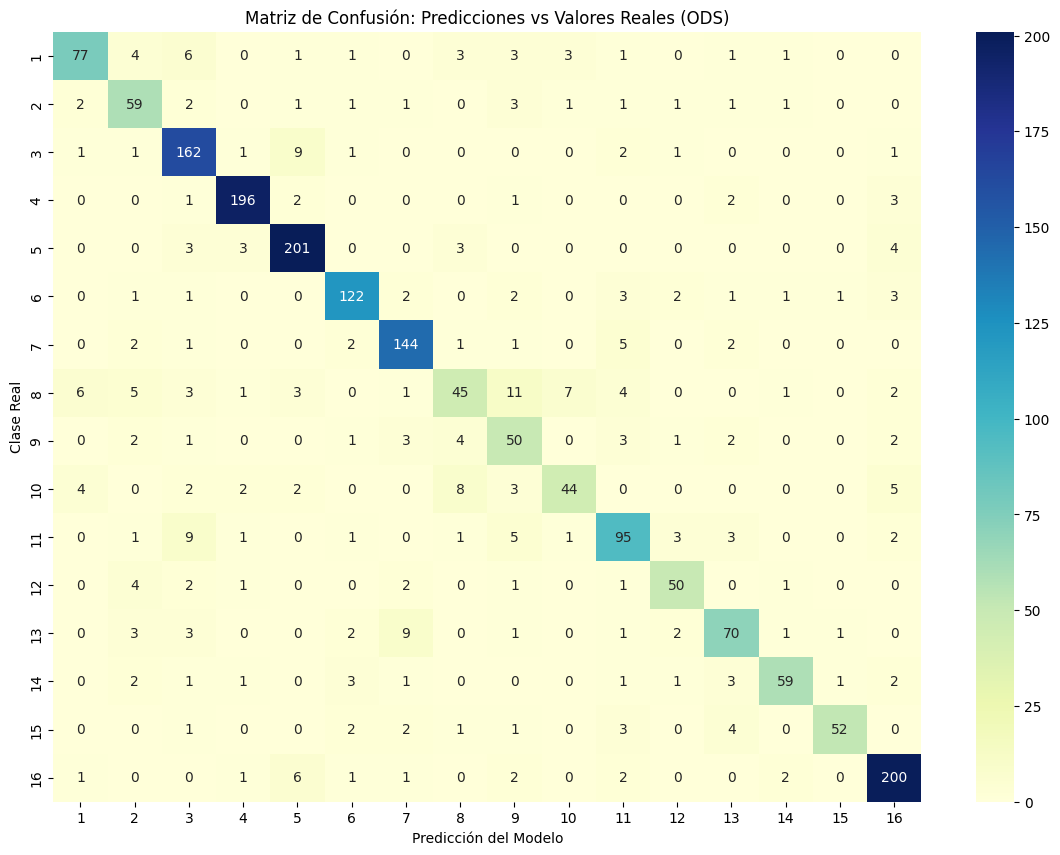

In [81]:
# Se define el mejor modelo (Pipeline completo: TF-IDF + SVD + Clasificador)
mejor_modelo_ods = grid_search.best_estimator_

# Se obtienen las predicciones del conjunto de prueba
y_pred = mejor_modelo_ods.predict(X_test)

# Se imprime el reporte detallado
print("REPORTE DE CLASIFICACIÓN FINAL ###")
print(classification_report(y_test, y_pred))

# Se imprime la matriz de Confusión
plt.figure(figsize=(14, 10))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=grid_search.classes_, 
            yticklabels=grid_search.classes_)
plt.title('Matriz de Confusión: Predicciones vs Valores Reales (ODS)')
plt.ylabel('Clase Real')
plt.xlabel('Predicción del Modelo')
plt.show()

---
---

### Validación del modelo con 5 muestras del conjunto de validación

In [92]:
# Se seleccionan 5 ejemplos aleatorios del conjunto de prueba (que no se usaron en el entrenamiento del modelo)
muestras_test = X_test.sample(5, random_state=42)
y_reales = y_test.loc[muestras_test.index]
y_predichas = mejor_modelo_ods.predict(muestras_test)

print("EVIDENCIA DE DESEMPEÑO: PRUEBA CON TEXTOS NO VISTOS ANTES POR EL MODELO\n")

for i in range(len(muestras_test)):
    print(f"Texto {i+1}:")
    # Se muestran los primeros 500 caracteres para leer el texto que se esté probando
    print(f"Contenido: {muestras_test.iloc[i][:500]}...") 
    print(f"VALOR REAL: ODS {y_reales.iloc[i]}")
    print(f"PREDICCIÓN: ODS {y_predichas[i]}")
    
    # Verificación rápida
    estado = "CORRECTO" if y_reales.iloc[i] == y_predichas[i] else "ERROR"
    print(f"Resultado: {estado}")
    print("-" * 50)
    print("\n")

EVIDENCIA DE DESEMPEÑO: PRUEBA CON TEXTOS NO VISTOS ANTES POR EL MODELO

Texto 1:
Contenido: defender principal donante volver modulado abierto parte interesado recientemente reconocido preocupado impacto ecológico desplazamiento población local minoría respectivo país resultado social cultural económico localizado indeseable cambiar beneficiar perder cuestionar análisis social defender proyecto escala región MRC particular poder abrir él voz investigación foro internacional discutir política resultado proyecto lugar propuesta gestión integrado recurso hídrico IWRM apoyo institución don...
VALOR REAL: ODS 6
PREDICCIÓN: ODS 16
Resultado: ERROR
--------------------------------------------------


Texto 2:
Contenido: gasto per cápita proyectar suposición específico multiplicar población específico grupo año proyección costo promedio individuo grupo edad deber disminuir tiempo razón suponer ganancia longevidad traducir año adicional salud envejecimiento saludable principal costo salud pres

---
---

### EXPORTANDO EL OBJETO PARA STREAMLIT
- Se optó por un diseño de pipeline desacoplado: durante el entrenamiento, el preprocesamiento con spaCy se realizó de forma independiente y paralela (n_process=-1) para optimizar el tiempo de cómputo.
  
- Para el despliegue en Streamlit, se construyó un nuevo pipeline de inferencia que integra la función de limpieza, garantizando que la aplicación sea reciba texto crudo y entregue una clasificación

In [100]:
# Recibe una lista de textos y devuelve la lista limpia
def pipeline_limpieza(textos):
    return [limpieza_textos(t) for t in textos]

# Se crea el Pipeline final que será utilizado en Streamlit
pipeline_streamlit = Pipeline([
    ('preprocesamiento', FunctionTransformer(pipeline_limpieza)),
    ('modelo_ods', mejor_modelo_ods)
])

# Guardamos este objeto completo
joblib.dump(pipeline_streamlit, './modelo_final_ods.joblib', compress=3)

['./modelo_final_ods.joblib']